# Numerically solving the Schrodinger equation

In this assignment you will use [<tt>qmsolve</tt>](https://github.com/quantum-visualizations/qmsolve) to solve the time-independent Schrodinger equation in one dimension and plot the solutions.

### First, install <tt>qmsolve</tt> in one of two ways:
<ul>
    <li>From a <tt>unix</tt> command line, type <tt>pip install qmsolve</tt></li>
    <li>Put the following commands in a code cell in this notebook and execute:<br />
        <tt>import sys</tt><br />
        <tt>!{sys.executable} -m pip install qmsolve</tt></li>
</ul>

### Homework problems:

<ol start=0>
    <li>Follow the link to the <tt>qmsolve</tt> GitHub page above. Click the link for the <tt>examples</tt> folder, then click on the <tt>eigenstate solver examples</tt> folder. Finally, click on <tt>1D_harmonic_oscillator.py</tt> to see a short code snippet that will calculate wavefunctions for a simple harmonic oscillator (SHO).</li>
    <li><tt>1D_harmonic_oscillator.py</tt> imports the <tt>Hamiltonian</tt> class from <tt>qmsolve</tt>. In quantum mechanics, what is a Hamiltonian? Please use multiple sources to formulate your answer and cite those sources. For this problem, crowd-sourced references such as Wikipedia and stackexchange are acceptable.</li>
    <li>Which force law is defined in the function <tt>harmonic_oscillator()</tt> in cell 2 of this notebook?</li>
    <li>What are the eigenstates referred to in lines 22 and 23 in <tt>1D_harmonic_oscillator.py</tt>? Again, please use multiple sources to formulate your answer and cite those sources.
    <li>Code cells 1 and 2 below contain imported code from <tt>1D_harmonic_oscillator.py</tt>, including a visualization of eigenstate 0 of the SHO. In subsequent code cells, plot any five SHO eigenstates of your choice.</li>
</ol>

Note: you can write your answers to the non-code problems in a markdown cell. From within a new notebook cell, click the box with the downward-pointing arrow that says "Code" (on your Jupyter toolbar) and change to "Markdown". Then you can just type in the cell like a regular text file.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qmsolve import Hamiltonian, SingleParticle, init_visualization, Å, eV

Computing...
Took 0.014298439025878906
[ 13.8243627   41.46350403  69.08346722  96.68423227 124.26577906
 151.82808744 179.37113718 206.89490796 234.39937942 261.8845311
 289.35034249 316.79679298 344.22386192 371.63152856 399.01977209
 426.38857162 453.73790619 481.06775475 508.3780962  535.66890934
 562.9401729  590.19186555 617.42396585 644.63645231 671.82930335
 699.00249732 726.15601246 753.28982697 780.40391895 807.49826642]


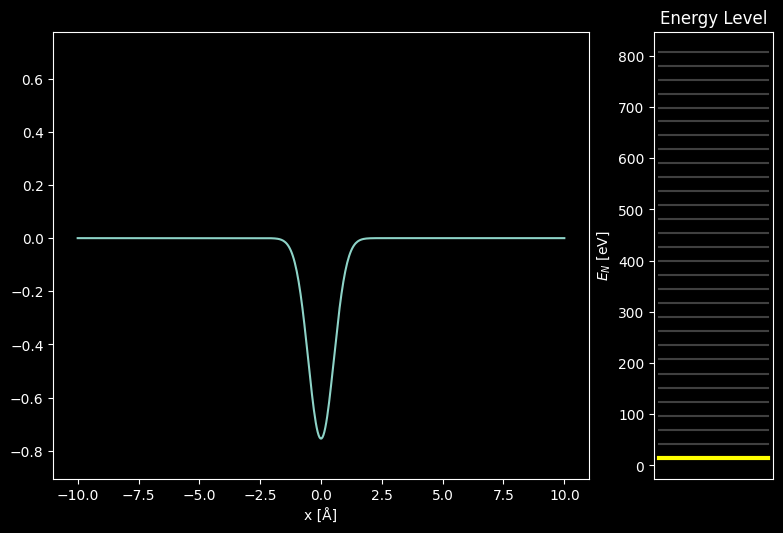

In [ ]:
# Harmonic oscillator potential
def harmonic_oscillator(particle):
    k = 100 * eV / Å**2
    return 0.5 * k * particle.x**2

# Define the Hamiltonian
H = Hamiltonian(particles = SingleParticle(), potential = harmonic_oscillator,
                spatial_ndim = 1, N = 512, extent = 20*Å)

#Diagonalize the Hamiltonian and compute the eigenstates
eigenstates = H.solve(max_states = 30)

# Print out the energies of the eigenstates
print(eigenstates.energies) # the printed energies are expressed in eV

# Visualize the Eigenstates
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(0)

**Problem 1.**  Hamiltonian is operator which is used to represents total energy of quantum systems, then thats equal to esentially kin. energy summed with poten. energy. The eigenvalues which correspond to it are the energy levels within whats possible for the system. It hence mandates what states evolve through across time by means of the Schrödinger equation [1, 2].

**Problem 2.** `harmonic_oscillator()` defines the Hooke's law which is esentially a linear restoring force for our purposes F = -k*x. and the  poten. energy is then given by V(x) = (1/2)*k*x^2.

**Problem 3.** eigenstates in this example are essentially wavefunctions corrresponding to a relevant ψ_n(x) stationary condition, they then satisfy H ψ_n = E_n ψ_n. Each state here possesses defined energy given by E_n, probability density of them do not change over time as a result [1, 2].

**Sources:**
[1] LibreTexts Physics, "The Hamiltonian Operator," in Quantum Mechanics (online open textbook)
[2] HyperPhysics (Georgia State University), "Schrödinger Equation" and "Particle in a Box" entries.

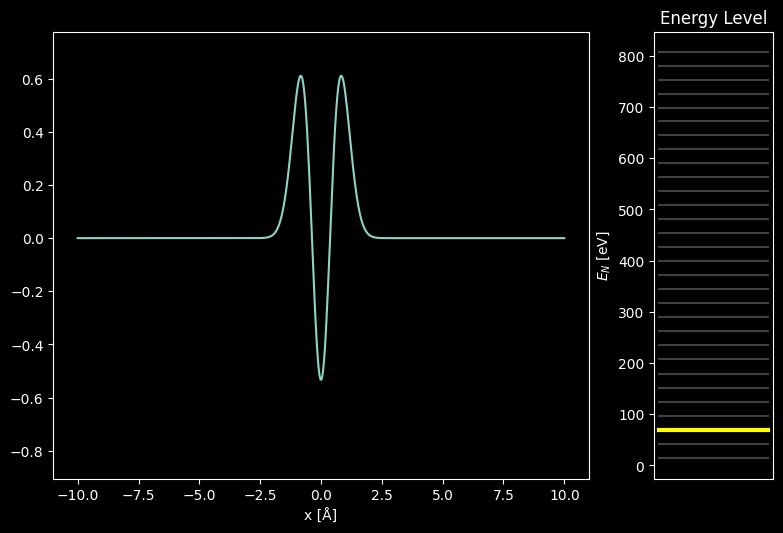

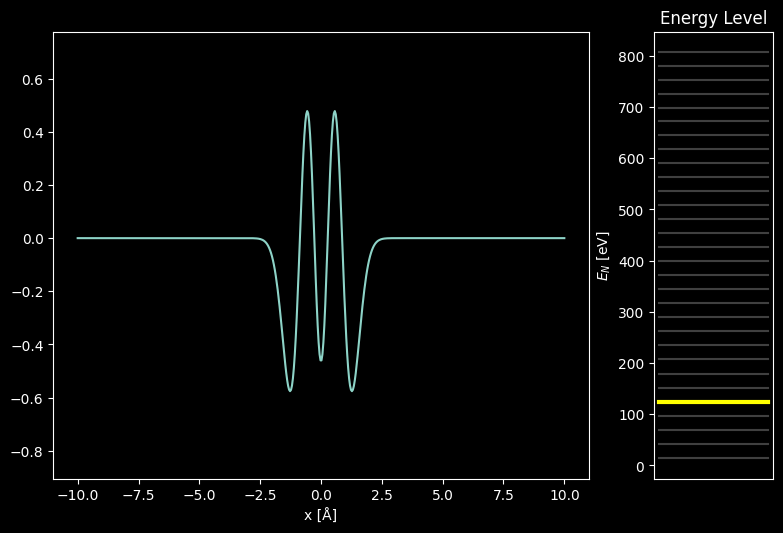

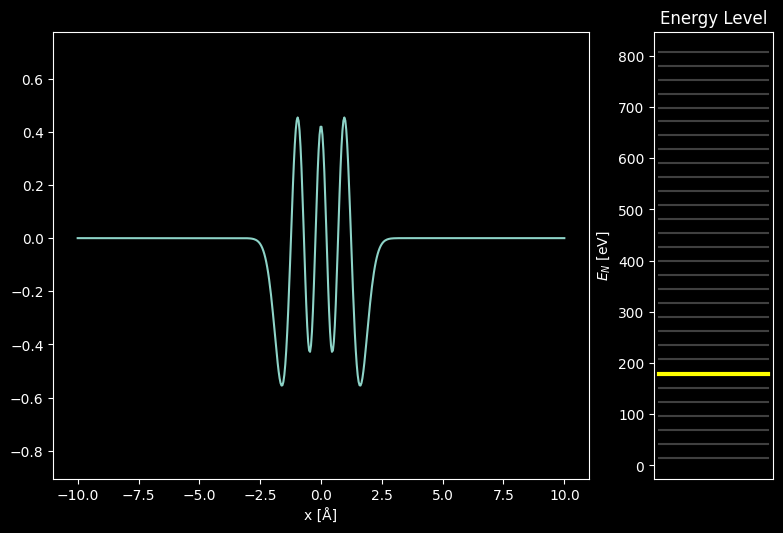

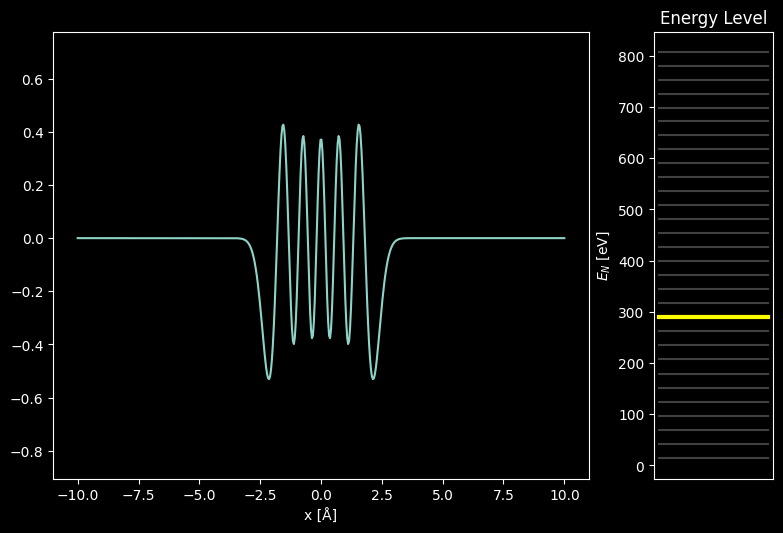

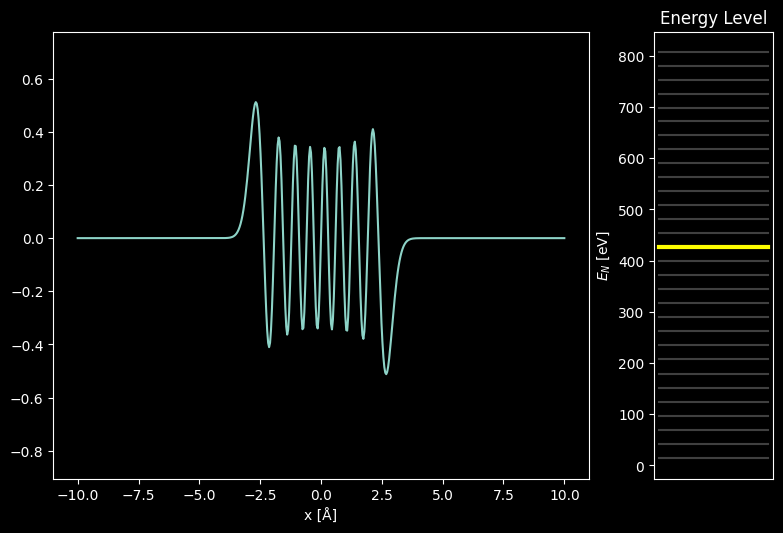

In [ ]:
# Problem 4
for n in [2, 4, 6, 10, 15]:
    visualization.plot_eigenstate(n)

<ol start=5>
    <li>What is on the x-axis of your plots?</li>
    <li>Are your plots showing wave functions $\psi(x)$ or probability functions $\psi^*(x) \psi(x)$? How do you know?</li>
</ol>

### New potential: infinite square well

Below I define the infinite square well potential for $L = 8$ Angstroms and plot the two lowest-energy eigenstates (compare to Figure 6.3 in your textbook).

**Problem 5.** The x axis shows the x in Ångströms.

**Problem 6.** wavefunctions ψ(x) the plots are showing, rather than probability density ψ*ψ. The curves effectively tell us this since they take on negative values, but definitionally the PDB needs to be positive or zero at each point.

Computing...
Took 0.008270263671875
[  0.58926935   2.35704264   5.30321556   9.4276143   14.7299955
  21.21004635  28.8673845   37.70155819  47.71204619  58.89825789
  71.2595333   84.79514311  99.50428872 115.3861023  132.43964681
 150.6639161  170.05783494 190.6202591  212.34997539 235.24570176
 259.30608737 284.52971266 310.91508944 338.46066097 367.16480207
 397.0258192  428.04195057 460.21136622 493.53216816 528.00239048]


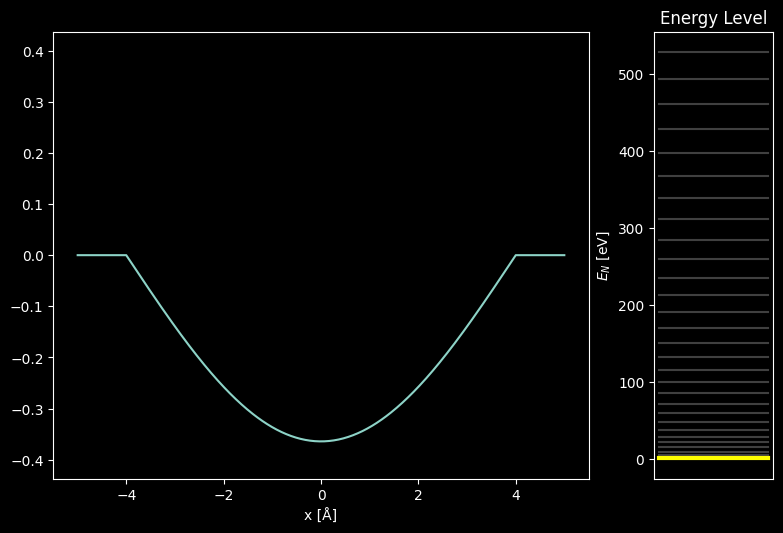

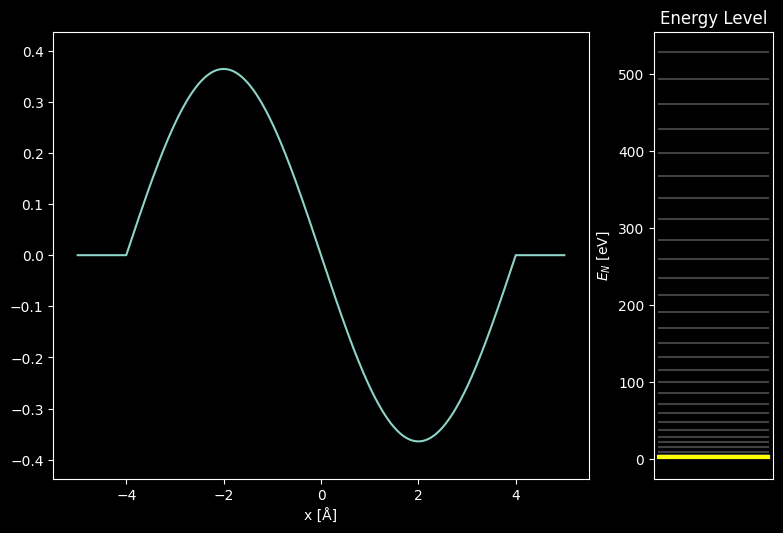

In [ ]:
# 8 angstrom-wide infinite square well
def infinite_square_well(particle):
    potential = np.zeros_like(particle.x)
    out_of_bounds = np.abs(particle.x) > 4*Å
    potential[out_of_bounds] = np.inf
    return potential

# Define the Hamiltonian of the infinite square well
H_sw = Hamiltonian(particles = SingleParticle(), potential = infinite_square_well,
                   spatial_ndim = 1, N = 512, extent = 10*Å)

# Diagonalize the Hamiltonian and compute the eigenstates
eigenstates_sw = H_sw.solve(max_states = 30)

print(eigenstates_sw.energies)

# Visualize the infinite square well eigenstates
visualization_sw = init_visualization(eigenstates_sw)
visualization_sw.plot_eigenstate(0)
visualization_sw.plot_eigenstate(1)

<ol start=7>
    <li>Plot any three infinite square well eigenstates of your choice.</li>
    <li>What property do the infinite square well eigenstates have that's different than the SHO eigenstates? (Hint: think about the properties of valid wave functions we discussed in class)</li>
    <li>What is the relationship between the number of extrema (maxima plus minima) in each eigenstate plot and the quantum number of the eigenstate?</li>
</ol>

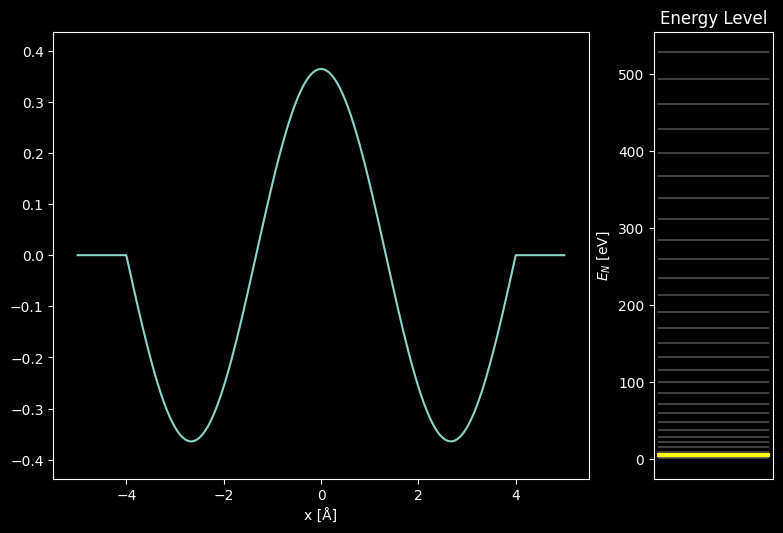

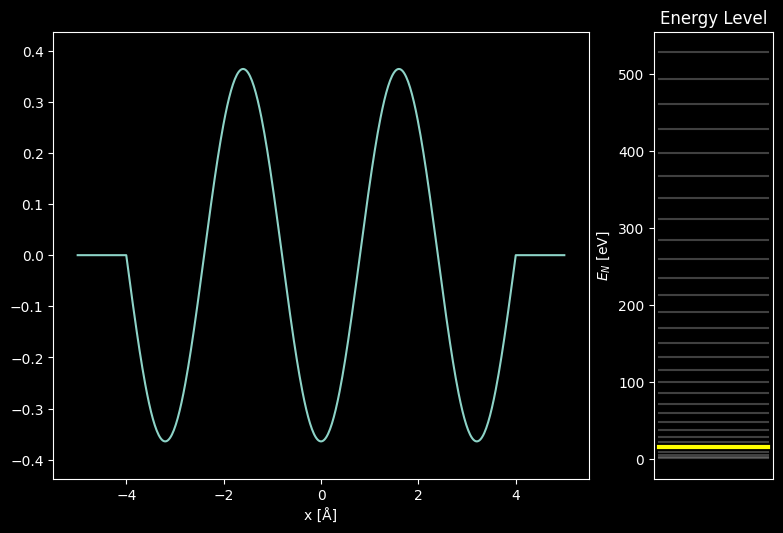

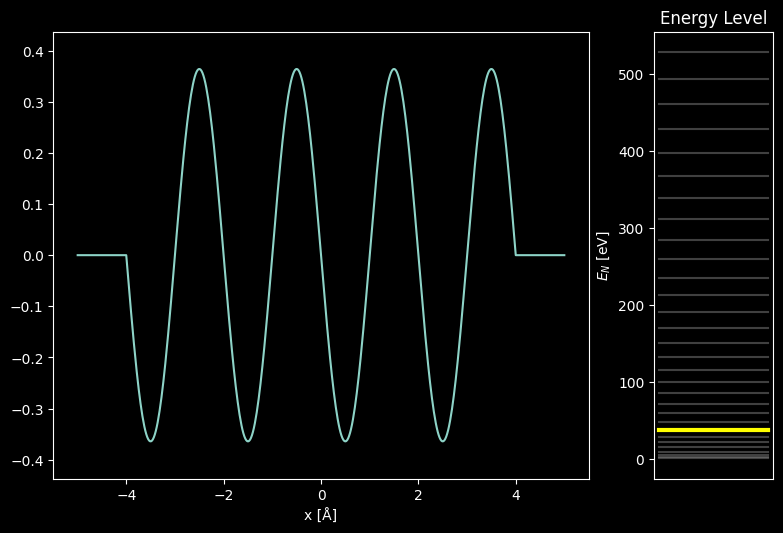

In [ ]:
# Problem 7
for n in [2, 4, 7]:
    visualization_sw.plot_eigenstate(n)

**Problem 8.** infinite square well with its corresponding eigenstates from a limit perspective approach 0 at the well's walls. The wavefunction goes away at those set of points corresponding to the set of points that potential value = infinite. SHO eigenstates posses as a result of this fact mathematically increasing and decaying ends which are brought out far through what would classically out of whats possible.

**Problem 9.** For our n eigenstate theres a given n+1 extrema points to consider which we have by: (with n = 0, 1, 2, and so on).

### Now it's your turn to define a potential

<ol start=10>
    <li>Write a function that defines a <em>finite square-well</em> potential (textbook section 5.4). You can choose the width of the well in Angstroms and the potential at the walls in eV. Calculate the finite square-well Hamiltonian and plot any five eigenstates you choose.</li>
    <li>Based on your plots, do you think a particle can get out of the finite square-well potential no matter its quantum number $n$?</li>
</ol>

Computing...
Took 0.007378339767456055
[  0.42410388   1.69020814   3.77953413   6.66068584  10.29114077
  14.62280811  19.61404136  25.24637182  31.53633595  38.53032862
  46.28246356  54.83077563  64.18625647  74.33587987  85.2526628
  96.90692968 109.27611499 122.3514588  136.13978345 150.65940977
 165.93173396 181.97228978 198.78518136 216.36263293 234.6889408
 253.74675528 273.52335061 294.01480965 315.22671007 337.17109707]


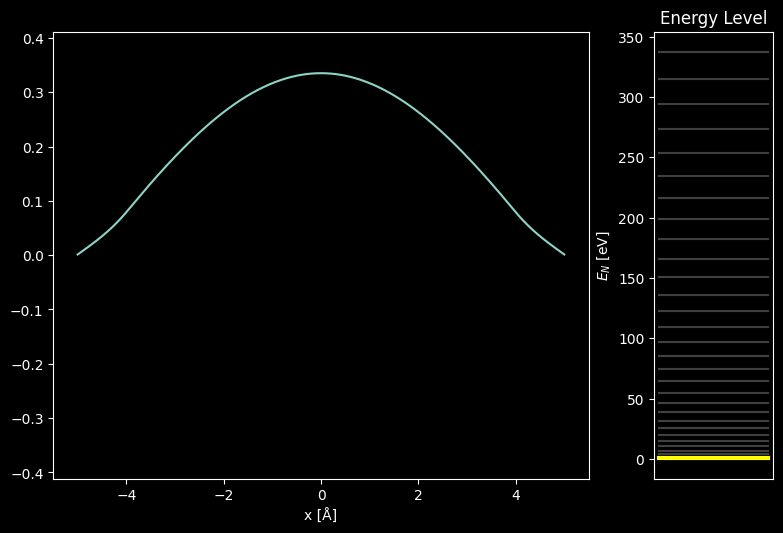

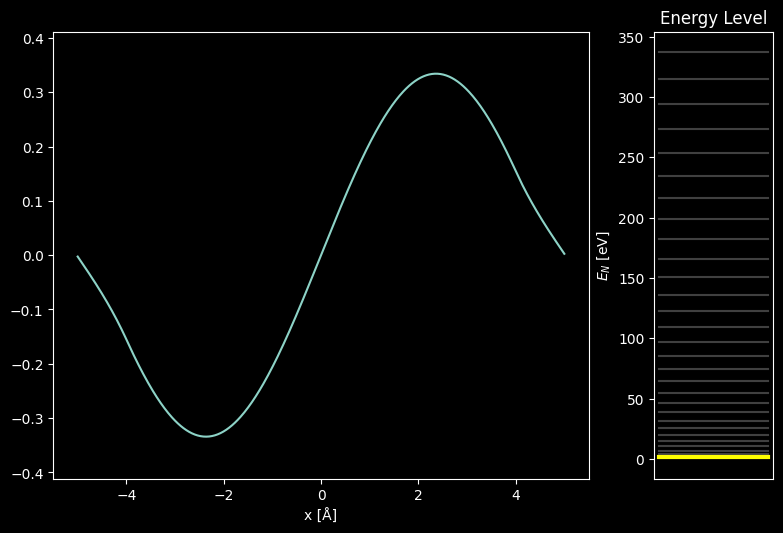

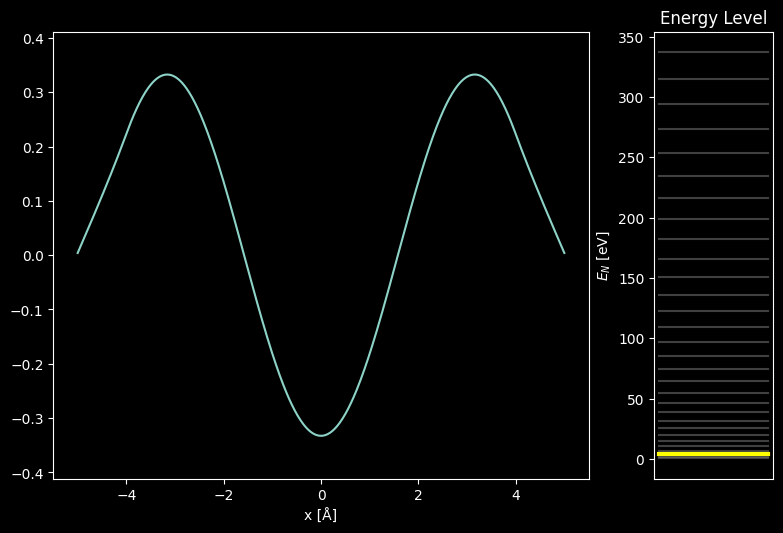

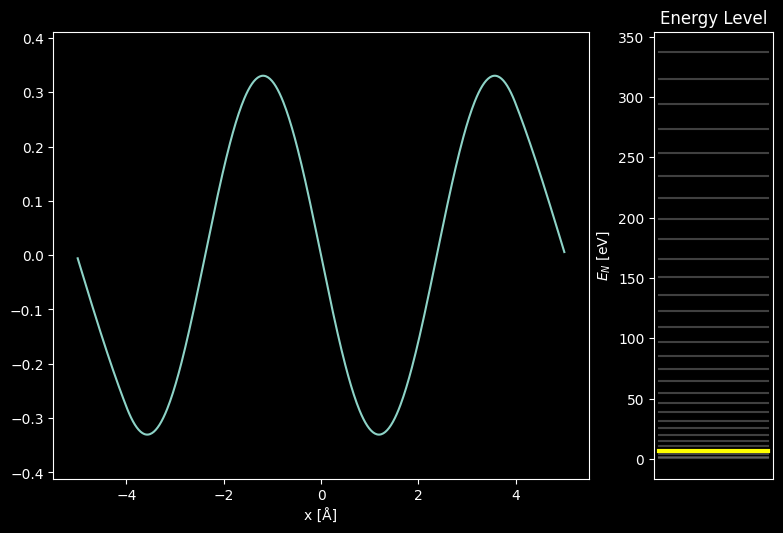

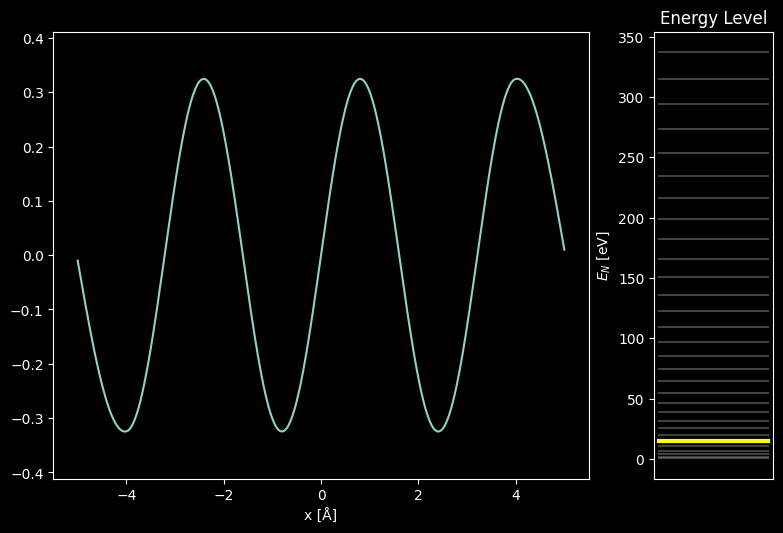

In [ ]:
# Problem 10
# angstrom-wide finite square well
def finite_square_well(particle):
    potential = np.zeros_like(particle.x)
    out_of_bounds = np.abs(particle.x) > 4*Å
    potential[out_of_bounds] = 5*eV  ### ADDED
    return potential

# Define the Hamiltonian of the finite square well
H_fsw = Hamiltonian(particles = SingleParticle(), potential = finite_square_well,
                   spatial_ndim = 1, N = 512, extent = 10*Å)

# Diagonalize the Hamiltonian and compute the eigenstates
eigenstates_fsw = H_fsw.solve(max_states = 30)

print(eigenstates_fsw.energies)

# Visualize the finite square well eigenstates
visualization_fsw = init_visualization(eigenstates_fsw)
visualization_fsw.plot_eigenstate(0)
visualization_fsw.plot_eigenstate(1)
visualization_fsw.plot_eigenstate(2)  ### ADDED
visualization_fsw.plot_eigenstate(3)  ### ADDED
visualization_fsw.plot_eigenstate(5)  ### ADDED

**Problem 11.** No. States corresponding to E_n lower than the wall potential are the only ones that have (5 eV) and are bound in the states and the Wave function is at that localized area inside the relevant well, and hence it has small quantitities of prob. density going futher through those corresponding walls. At the time where there's a correpsonding E_n that goes to a higher value as compared with wall potential, this particle as a result is unbound which corresponds to an effective escapes out of the confining well's wall.